In [7]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde

# ======================================================
# 0. 全局设置（ICML 风格）
# ======================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.linewidth": 2.5,
})

SEED = 42
NUM_SAMPLES = 2000
CACHE_DIR = "tsne_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

rng = np.random.default_rng(SEED)

# ======================================================
# 1. 读取四个 embedding
# ======================================================
data_dict = {
    "u_sim": torch.from_numpy(np.load("u_sim.npy")),
    "i_sim": torch.from_numpy(np.load("i_sim.npy")),
    "u_agg": torch.from_numpy(np.load("u_agg.npy")),
    "i_agg": torch.from_numpy(np.load("i_agg.npy")),
}

titles = [r"$\mathbf{F}^{(u)}$", r"$\mathbf{F}^{(v)}$", 
          r"$\widetilde{\mathbf{F}}^{(u)}$", 
          r"$\widetilde{\mathbf{F}}^{(v)}$"]

# ======================================================
# 2. t-SNE + 单位圆（带缓存，核心）
# ======================================================
def get_tsne_unit_projection(
    emb: torch.Tensor,
    name: str,
    num_samples: int = 2000,
    seed: int = 42,
    cache_dir: str = "tsne_cache",
):
    """
    返回:
        z_unit: (num_samples, 2) 已归一化到 S^1
    """
    cache_path = os.path.join(cache_dir, f"{name}_tsne_unit.npz")

    # ---------- 已缓存 ----------
    if os.path.exists(cache_path):
        data = np.load(cache_path)
        print(f"[Load cached t-SNE] {name}")
        return data["z_unit"]

    # ---------- 重新计算 ----------
    print(f"[Run sampling + t-SNE] {name}")
    rng = np.random.default_rng(seed)
    idx = rng.choice(emb.shape[0], size=num_samples, replace=False)
    sample = emb[idx].cpu().numpy()

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        max_iter=3000,   # sklearn >= 1.2
        init="pca",
        random_state=seed
    )

    z_2d = tsne.fit_transform(sample)
    z_unit = z_2d / np.linalg.norm(z_2d, axis=1, keepdims=True)

    np.savez(
        cache_path,
        z_unit=z_unit,
        indices=idx
    )

    return z_unit


# ======================================================
# 3. 环状 KDE（SimGCL 风格）
# ======================================================
def ring_kde(z_unit, grid=260, r_in=0.90, r_out=1.05):
    kde = gaussian_kde(z_unit.T)

    x = np.linspace(-1.1, 1.1, grid)
    y = np.linspace(-1.1, 1.1, grid)
    xx, yy = np.meshgrid(x, y)
    pos = np.vstack([xx.ravel(), yy.ravel()])
    dens = kde(pos).reshape(xx.shape)

    rr = np.sqrt(xx**2 + yy**2)
    dens[(rr < r_in) | (rr > r_out)] = np.nan

    return xx, yy, dens

[Load cached t-SNE] u_sim
[Load cached t-SNE] i_sim
[Load cached t-SNE] u_agg
[Load cached t-SNE] i_agg


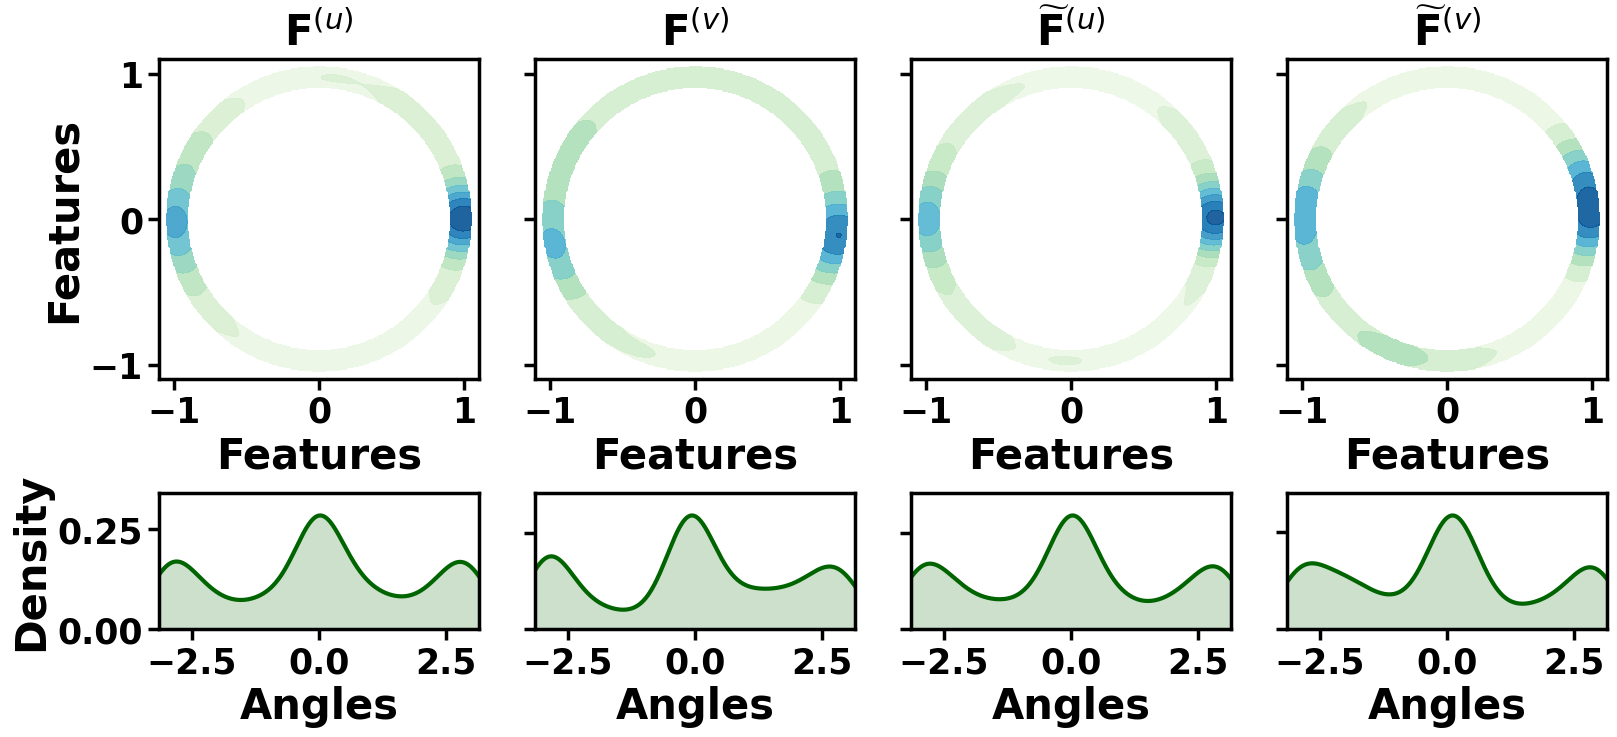

In [8]:
# ======================================================
# 4. Figure 布局：2 × 4（ICML 双栏友好）
# ======================================================
fig = plt.figure(figsize=(16, 7.6))

top_y = 0.38
bottom_y = 0.10
height_top = 0.52
height_bottom = 0.18
width = 0.20
gap = 0.035

# ======================================================
# 5. 主循环：四列
# ======================================================
for col, (name, emb) in enumerate(data_dict.items()):
    # ---------- t-SNE + S^1（缓存） ----------
    z_unit = get_tsne_unit_projection(
        emb,
        name=name,
        num_samples=NUM_SAMPLES,
        seed=SEED,
        cache_dir=CACHE_DIR
    )

    # ---------- KDE ----------
    xx, yy, dens = ring_kde(z_unit)

    # ==================================================
    # 上：圆环 KDE
    # ==================================================
    ax1 = fig.add_axes([
        0.05 + col * (width + gap),
        top_y,
        width,
        height_top
    ])

    ax1.contourf(
        xx, yy, dens,
        levels=7,            # SimGCL 是少层
        cmap="GnBu",         # ⭐ SimGCL 同款色系
        alpha=0.9
    )

    ax1.set_aspect("equal")
    ax1.set_xlim(-1.1, 1.1)
    ax1.set_ylim(-1.1, 1.1)

    ax1.set_title(titles[col], fontsize=30, fontweight="bold", pad=10)

    if col == 0:
        ax1.set_ylabel("Features", fontsize=30, fontweight="bold")
    else:
        ax1.set_yticklabels([])

    ax1.set_xlabel("Features", fontsize=30, fontweight="bold")
    ax1.tick_params(width=2)

    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)

    ax1.tick_params(
        axis='both',
        which='major',
        labelsize=25,      # 刻度字体变大
        width=2.5,         # 刻度线加粗
        length=8           # 刻度线变长
    )
    
    for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
        tick.set_fontweight('bold')

    # ==================================================
    # 下：角度密度
    # ==================================================
    angles = np.arctan2(z_unit[:, 1], z_unit[:, 0])
    angle_kde = gaussian_kde(angles)

    theta = np.linspace(-np.pi, np.pi, 500)
    dens_theta = angle_kde(theta)

    ax2 = fig.add_axes([
        0.05 + col * (width + gap),
        bottom_y,
        width,
        height_bottom
    ])

    ax2.plot(
        theta, dens_theta,
        color="darkgreen",
        linewidth=3
    )

    ax2.fill_between(
        theta, dens_theta,
        color="darkgreen",
        alpha=0.20
    )

    ax2.set_xlim(-np.pi, np.pi)
    ax2.set_ylim(0, dens_theta.max() * 1.2)

    if col == 0:
        ax2.set_ylabel("Density", fontsize=30, fontweight="bold")
    else:
        ax2.set_yticklabels([])

    ax2.set_xlabel("Angles", fontsize=30, fontweight="bold")
    ax2.tick_params(width=2)

    for spine in ax2.spines.values():
        spine.set_linewidth(2.5)

    ax2.tick_params(
        axis='both',
        which='major',
        labelsize=25,
        width=2.5,
        length=8
    )
    
    for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
        tick.set_fontweight('bold')

plt.savefig(
    "tmall_embedding_distribution.png",
    format="png",
    bbox_inches="tight",   # 去除多余白边（非常重要）
    pad_inches=0.12        # 保留极小安全边距
)

plt.show()